In [5]:
import jax.numpy as jnp
import jax
from core.utils import *
from core.model import SparseHyperelasticityGP
from core.material_models import get_material
from core.datasetclass import BenchmarkDataset

In [2]:
from dolfinx import log, default_scalar_type
from dolfinx.fem.petsc import NonlinearProblem
import numpy as np
from dolfinx.io.gmsh import read_from_msh
import ufl
import gmsh
from mpi4py import MPI
from dolfinx import fem, mesh, plot

In [7]:
gmsh.initialize()
gdim = 2
model = gmsh.model.occ
L_x = 1.0
L_y = 1.0
R_hole = 0.1
mesh_size = 0.05
# 2. Create rectangle
rect = model.addRectangle(0.0, 0.0, 0.0, L_x, L_y)

# 3. Create circle
circle = model.addDisk(0.0, 0.0, 0.0, R_hole, R_hole)

# 4. Cut the hole
domain_with_hole, _ = model.cut([(gdim, rect)], [(gdim, circle)])
gmsh.model.occ.synchronize()

# 5. Physical group
gmsh.model.addPhysicalGroup(gdim, [rect], 1)
gmsh.model.setPhysicalName(gdim, 1, "domain")
gmsh.option.setNumber("Mesh.CharacteristicLengthMin", mesh_size)
gmsh.option.setNumber("Mesh.CharacteristicLengthMax", mesh_size)
gmsh.model.mesh.generate(gdim)
# 6. Mesh generation
gmsh.model.mesh.generate(gdim)

# 7. Write to file
gmsh.write("mesh.msh")
gmsh.finalize()

# 8. Read into DOLFINx
mesh_ = read_from_msh("mesh.msh", MPI.COMM_WORLD, 0, gdim)

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Ellipse)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 50%] Meshing curve 3 (Line)
Info    : [ 70%] Meshing curve 4 (Line)
Info    : [ 90%] Meshing curve 5 (Line)
Info    : Done meshing 1D (Wall 0.000851007s, CPU 0s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0141073s, CPU 0.008147s)
Info    : 521 nodes 1045 elements
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00898805s, CPU 0.008836s)
Info    : 521 nodes 1045 elements
Info    : Writing 'mesh.msh'...
Info    : Done writing 'mesh.msh'
Info    : Reading 'mesh.msh'...
Info    : 11 entities
Info    : 521 nodes
Info    : 960 elements
Info    : Done reading 'mesh.msh'


In [3]:
msh_data = read_from_msh("mesh.msh", MPI.COMM_WORLD, 0, 2) 
domain = msh_data.mesh

node_coords = domain.geometry.x[:, :2]  # numpy array
num_nodes, gdim = node_coords.shape
# 3. Extract cell connectivity (triangles)
tdim = domain.topology.dim
domain.topology.create_connectivity(tdim, 0)
cells = domain.geometry.dofmap

np.savez("mesh/mesh.npz", node_coords = node_coords, cells = cells)

Info    : Reading 'mesh.msh'...
Info    : 11 entities
Info    : 1412 nodes
Info    : 2688 elements
Info    : Done reading 'mesh.msh'


In [5]:
# Import some useful modules.
import jax
import jax.numpy as jnp
import os

# Import JAX-FEM specific modules.
from jax_fem.problem import Problem
from jax_fem.solver import solver
from jax_fem.utils import save_sol
from jax_fem.generate_mesh import box_mesh_gmsh, get_meshio_cell_type, Mesh
import jax.random as jr 
jax.config.update("jax_enable_x64", True)

from core.utils import *
from core.model import SparseHyperelasticityGP, GPParams, GPRawParams
from core.material_models import get_material
from core.datasetclass import BenchmarkDataset

[02-03 10:04:02][INFO] jax_fem: pyamgx not installed. AMGX solver disabled.


       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              



In [6]:
model_path = "/home/mmdiscovery/shared/selected_model/Isihara/" # Replace with the actual path to your saved model
with open(os.path.join(model_path, "best_params.npy"), "rb") as f:
    best_params = jnp.load(f, allow_pickle=True).item()

with open(os.path.join(model_path, "I_z.npy"), "rb") as f:
    I_z = jnp.load(f)

In [7]:
best_raw_params = GPRawParams(**best_params)

In [20]:
model.load_params(best_raw_params)

NameError: name 'model' is not defined

In [8]:
def calculate_min_ls(z):
    # For a 2D/3D point cloud, a quick way is to use the 
    # average distance to the nearest neighbor.
    from sklearn.neighbors import NearestNeighbors
    nbrs = NearestNeighbors(n_neighbors=2).fit(z)
    distances, _ = nbrs.kneighbors(z)
    avg_dist = jnp.mean(distances[:, 1])
    return avg_dist * 0.5 # Minimum allowable lengthscale

In [9]:
dev_z = I_z[:, :2]
vol_z = I_z[:, 2:]
min_dev = calculate_min_ls(dev_z)
min_vol = calculate_min_ls(vol_z)

In [10]:
learned_gp = SparseHyperelasticityGP(best_raw_params, I_z, min_dev, min_vol)

Array(0.12651, dtype=float64)

In [11]:

# Define constitutive relationship.
class HyperElasticity(Problem):
    def __init__(self, material_model_piola_stress, **kwargs) :
        super().__init__(**kwargs)
        self.material_model_piola_stress = material_model_piola_stress # should be function outputing piola stress [2x2 matrix]
    def custom_init(self):
        self.fe = self.fes[0]
    def get_surface_maps(self):
        def surface_map(u, x, load):
            return jnp.array([0., -load[0]])
        return [surface_map]
    def set_params(self, params):
        surface_params = params
        self.internal_vars_surfaces = [[surface_params]]
    def get_tensor_map(self):

        def first_PK_stress(u_grad):
            I = jnp.eye(self.dim)
            F = u_grad + I
            P = self.material_model_piola_stress(F)
            return P

        return first_PK_stress
    
# Specify mesh-related information (first-order hexahedron element).
mesh_data = jnp.load("/home/mmdiscovery/shared/mesh/mesh.npz")
node_coords = mesh_data["node_coords"]
cells = mesh_data["cells"]
ele_type = 'TRI3'
cell_type = get_meshio_cell_type(ele_type)
data_dir = os.path.join('data')

mesh = Mesh(node_coords, cells)


# Define boundary locations.
def left(point):
    return jnp.isclose(point[0], 0., atol=1e-6)
def bottom(point):
    return jnp.isclose(point[1], 0., atol=1e-6)
def right(point):
    return jnp.isclose(point[0], 1., atol=1e-6)
def top(point):
    return jnp.isclose(point[1], 1.0, atol=1e-6)

zero_dbc = lambda point : 0
top_dbc = lambda point : 0.1
dirichlet_bc_info = [
    [bottom] * 2 , 
    [0, 1],
    [zero_dbc, zero_dbc]
                     ]
true_material_model = get_material("isihara")
true_piola_stress_func = lambda f : true_material_model.P(fto3x3(f))[:2, :2]

learned_gp = SparseHyperelasticityGP(best_raw_params, I_z, min_dev, min_vol)

pred_piola_stress_func = lambda f: learned_gp.piola(fto3x3(f), key = None)[:2, :2]

# # Create an instance of the problem.
problem_true = HyperElasticity(mesh = mesh,
                          vec=2,
                          dim=2,
                          ele_type=ele_type,
                          dirichlet_bc_info=dirichlet_bc_info,
                          location_fns = [top],
                          material_model_piola_stress=true_piola_stress_func)

problem_pred = HyperElasticity(mesh = mesh,
                          vec=2,
                          dim=2,
                          ele_type=ele_type,
                          dirichlet_bc_info=dirichlet_bc_info,
                          location_fns = [top],
                          material_model_piola_stress=pred_piola_stress_func)
petsc_options = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt", 
    "ksp_type": "gmres",
    "pc_type": "hypre",
    "ksp_rtol": 1e-5,  # Force higher accuracy in the linear solve
    "ksp_atol": 1e-8,
}
loads = jnp.linspace(0.1, 4.0, 10)
# Solve the defined problem.

# u_true = jnp.zeros_like(node_coords)

def solve_fem(problem, petsc_options, loads) :
    u = jnp.zeros_like(problem.mesh[0].points)
    for i, load in enumerate(loads):
        print("load step ", i, "= ", load)
        shape = (len(problem.boundary_inds_list[0]), problem.fes[0].num_face_quads, 1)
        problem.internal_vars_surfaces = [
            [
                jnp.full(fill_value=load, shape=shape),
            ]
        ]
        u = solver(problem, solver_options={'petsc_solver': petsc_options,
                                                'initial_guess': u})[0]
    return u

u_true = solve_fem(problem_true, petsc_options, loads)
def piola(f, key) :
    piola_mean = learned_gp.piola_dist(f).mean
    piola_var = learned_gp.piola_dist(f).var
    return piola_mean + jax.random.normal(key, piola_mean.shape) * piola_var

main_key = jr.PRNGKey(42)
n_samples = 5
u_samples = []
for i in range(n_samples) :
    main_key, subkey = jr.split(main_key)
    # u_pred = jnp.zeros_like(node_coords)

    pred_piola_stress_func = lambda f: piola(fto3x3(f), key = subkey)[:2, :2]
    problem_pred = HyperElasticity(mesh = mesh,
                            vec=2,
                            dim=2,
                            ele_type=ele_type,
                            dirichlet_bc_info=dirichlet_bc_info,
                            location_fns = [top],
                            material_model_piola_stress=pred_piola_stress_func)
    u_pred = solve_fem(problem_pred, petsc_options, loads)
    u_samples.append(u_pred)

[02-03 10:04:32][DEBUG] jax_fem: Computing shape function values, gradients, etc.


[02-03 10:04:32][DEBUG] jax_fem: ele_type = TRI3, quad_points.shape = (num_quads, dim) = (1, 2)
[02-03 10:04:32][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (3, 1, 2)
[02-03 10:04:33][DEBUG] jax_fem: Done pre-computations, took 0.6854872703552246 [s]
[02-03 10:04:33][INFO] jax_fem: Solving a problem with 2688 cells, 1412x2 = 2824 dofs.
[02-03 10:04:33][INFO] jax_fem: Element type is TRI3, using 1 quad points per element.
[02-03 10:04:34][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[02-03 10:04:34][DEBUG] jax_fem: ele_type = TRI3, quad_points.shape = (num_quads, dim) = (1, 2)
[02-03 10:04:34][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (3, 1, 2)
[02-03 10:04:34][DEBUG] jax_fem: Done pre-computations, took 0.011357307434082031 [s]
[02-03 10:04:34][INFO] jax_fem: Solving a problem with 2688 cells, 1412x2 = 2824 dofs.
[02-03 10:04:34][INFO] jax_fem: Element type is TRI3, using 1 quad points per element.
[0

load step  0 =  0.1


[02-03 10:04:37][DEBUG] jax_fem: Function split_and_compute_cell took 2.5677 seconds
[02-03 10:04:38][DEBUG] jax_fem: Creating sparse matrix with scipy...
[02-03 10:04:38][DEBUG] jax_fem: Before, l_2 res = 0.017023289562926803, relative l_2 res = 1.0
[02-03 10:04:38][DEBUG] jax_fem: Solving linear system...
[02-03 10:04:38][DEBUG] jax_fem: PETSc Solver - Solving linear system with ksp_type = gmres, pc = hypre
[02-03 10:04:38][DEBUG] jax_fem: PETSc Solver - Finished solving, linear solve res = 3.963954055010685e-06
[02-03 10:04:38][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[02-03 10:04:38][DEBUG] jax_fem: Function split_and_compute_cell took 0.0124 seconds
[02-03 10:04:38][DEBUG] jax_fem: Creating sparse matrix with scipy...
[02-03 10:04:38][DEBUG] jax_fem: l_2 res = 0.0003992750751985916, relative l_2 res = 0.02345463687982668
[02-03 10:04:38][DEBUG] jax_fem: Solving linear system...
[02-03 10:04:38][DEBUG] jax_fem: PETSc Solver - Solving linear system with ksp_type 

load step  1 =  0.5333333333333333


...

[02-03 10:06:33][DEBUG] jax_fem: Function split_and_compute_cell took 0.2380 seconds
[02-03 10:06:33][DEBUG] jax_fem: Creating sparse matrix with scipy...
[02-03 10:06:33][DEBUG] jax_fem: Before, l_2 res = 0.07376758942470601, relative l_2 res = 1.0
[02-03 10:06:33][DEBUG] jax_fem: Solving linear system...
[02-03 10:06:33][DEBUG] jax_fem: PETSc Solver - Solving linear system with ksp_type = gmres, pc = hypre
[02-03 10:06:33][DEBUG] jax_fem: PETSc Solver - Finished solving, linear solve res = 2.6340568853220817e-05
[02-03 10:06:34][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[02-03 10:06:34][DEBUG] jax_fem: Function split_and_compute_cell took 0.2074 seconds
[02-03 10:06:34][DEBUG] jax_fem: Creating sparse matrix with scipy...
[02-03 10:06:34][DEBUG] jax_fem: l_2 res = 0.012434440692137432, relative l_2 res = 0.16856238341404886
[02-03 10:06:34][DEBUG] jax_fem: Solving linear system...
[02-03 10:06:34][DEBUG] jax_fem: PETSc Solver - Solving linear system with ksp_type =

load step  8 =  3.5666666666666664


[02-03 10:06:35][DEBUG] jax_fem: Function split_and_compute_cell took 0.2228 seconds
[02-03 10:06:35][DEBUG] jax_fem: Creating sparse matrix with scipy...
[02-03 10:06:35][DEBUG] jax_fem: Before, l_2 res = 0.07376758678855268, relative l_2 res = 1.0
[02-03 10:06:35][DEBUG] jax_fem: Solving linear system...
[02-03 10:06:35][DEBUG] jax_fem: PETSc Solver - Solving linear system with ksp_type = gmres, pc = hypre
[02-03 10:06:35][DEBUG] jax_fem: PETSc Solver - Finished solving, linear solve res = 2.827874684034018e-05
[02-03 10:06:35][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[02-03 10:06:35][DEBUG] jax_fem: Function split_and_compute_cell took 0.2009 seconds
[02-03 10:06:35][DEBUG] jax_fem: Creating sparse matrix with scipy...
[02-03 10:06:35][DEBUG] jax_fem: l_2 res = 0.02318928185345247, relative l_2 res = 0.3143559775097727
[02-03 10:06:35][DEBUG] jax_fem: Solving linear system...
[02-03 10:06:35][DEBUG] jax_fem: PETSc Solver - Solving linear system with ksp_type = gm

load step  9 =  4.0


[02-03 10:06:36][DEBUG] jax_fem: Function split_and_compute_cell took 0.2228 seconds
[02-03 10:06:36][DEBUG] jax_fem: Creating sparse matrix with scipy...
[02-03 10:06:36][DEBUG] jax_fem: Before, l_2 res = 0.07376758806096877, relative l_2 res = 1.0
[02-03 10:06:36][DEBUG] jax_fem: Solving linear system...
[02-03 10:06:36][DEBUG] jax_fem: PETSc Solver - Solving linear system with ksp_type = gmres, pc = hypre
[02-03 10:06:36][DEBUG] jax_fem: PETSc Solver - Finished solving, linear solve res = 1.817050946672821e-05
[02-03 10:06:36][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[02-03 10:06:36][DEBUG] jax_fem: Function split_and_compute_cell took 0.2196 seconds
[02-03 10:06:36][DEBUG] jax_fem: Creating sparse matrix with scipy...
[02-03 10:06:36][DEBUG] jax_fem: l_2 res = 0.022041073188127706, relative l_2 res = 0.2987907530596066
[02-03 10:06:36][DEBUG] jax_fem: Solving linear system...
[02-03 10:06:36][DEBUG] jax_fem: PETSc Solver - Solving linear system with ksp_type = g

In [12]:
len(u_samples)

5

In [13]:
u_samples_array = jnp.array(u_samples)


In [14]:
u_samples_mean = jnp.mean(u_samples_array, axis = 0)
u_samples_std = jnp.std(u_samples_array, axis = 0)

In [15]:
u_pred = u_samples_mean

In [16]:
u_std = u_samples_std

<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_784/1453115200.py:50: SyntaxWarning: invalid escape sequence '\m'
  fig.colorbar(tpc3, ax=ax3, label='Error: $||\mu - u_{true}||$')
/tmp/ipykernel_784/1453115200.py:57: SyntaxWarning: invalid escape sequence '\s'
  fig.colorbar(tpc4, ax=ax4, label='Uncertainty: $||\sigma_{pred}||$')
/tmp/ipykernel_784/1453115200.py:58: SyntaxWarning: invalid escape sequence '\s'
  ax4.set_title('Predicted Std ($\sigma$)', fontsize=12, fontweight='bold')


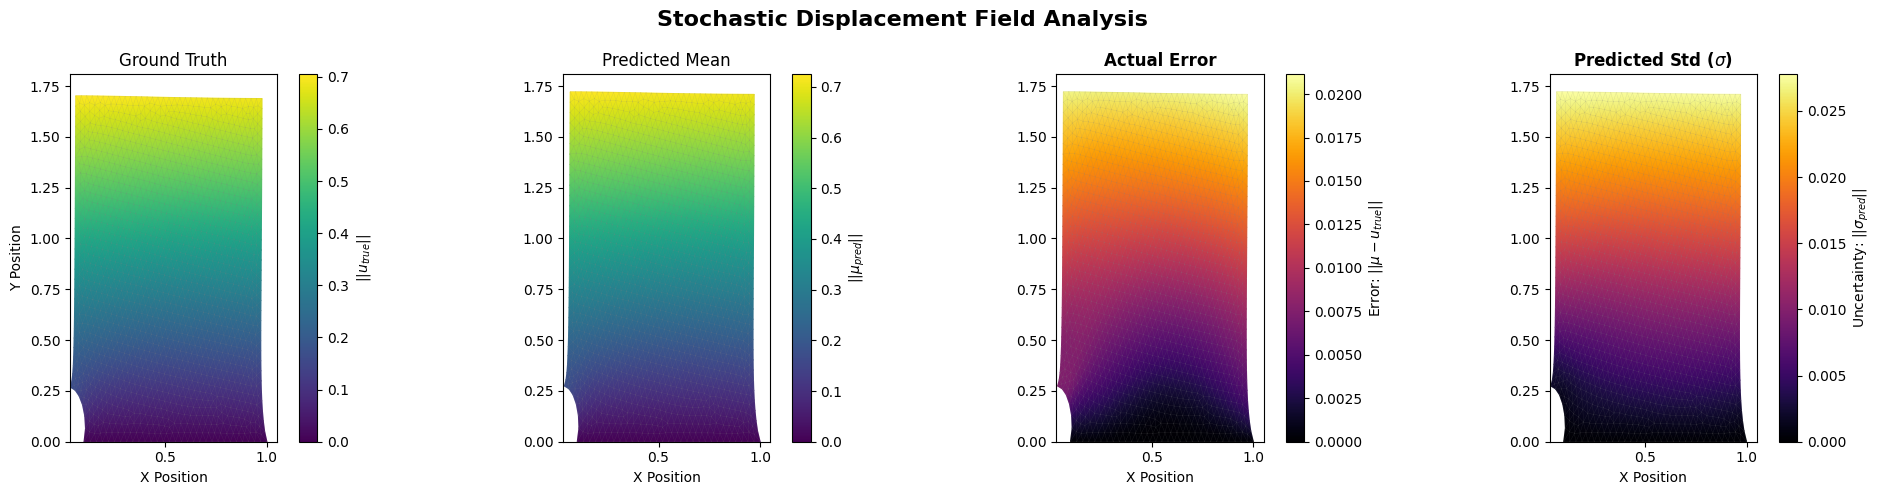

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# --- 1. Calculations ---
# Magnitude of True and Predicted (Mean)
u_true_mag = np.linalg.norm(u_true, axis=1)
u_pred_mag = np.linalg.norm(u_pred, axis=1)

# Accuracy Metric: Absolute Error Magnitude
u_error_mag = np.linalg.norm(u_true - u_pred, axis=1)

# Uncertainty Metric: Magnitude of the Standard Deviation vector
# This represents the total nodal uncertainty
u_std_mag = np.linalg.norm(u_std, axis=1) 

# Deformed nodal positions for the Predicted domain
wp_true = node_coords[:, :2] + u_true
wp_pred = node_coords[:, :2] + u_pred

# --- 2. Scale Synchronization ---
all_x = np.concatenate([wp_true[:, 0], wp_pred[:, 0]])
all_y = np.concatenate([wp_true[:, 1], wp_pred[:, 1]])
x_lims = (all_x.min() * 0.95, all_x.max() * 1.05)
y_lims = (all_y.min() * 0.95, all_y.max() * 1.05)

# Triangulations
tri_true = tri.Triangulation(wp_true[:, 0], wp_true[:, 1], cells)
tri_pred = tri.Triangulation(wp_pred[:, 0], wp_pred[:, 1], cells)

# --- 3. Plotting (4-Panel Comparison) ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5), facecolor='white')
fig.suptitle('Stochastic Displacement Field Analysis', fontsize=16, fontweight='bold')

# Plot 1: True Ground Truth
ax1 = axes[0]
tpc1 = ax1.tripcolor(tri_true, u_true_mag, cmap="viridis", shading='gouraud')
fig.colorbar(tpc1, ax=ax1, label='$||u_{true}||$')
ax1.set_title('Ground Truth', fontsize=12)

# Plot 2: Mean Prediction
ax2 = axes[1]
tpc2 = ax2.tripcolor(tri_pred, u_pred_mag, cmap="viridis", shading='gouraud')
fig.colorbar(tpc2, ax=ax2, label='$||\\mu_{pred}||$')
ax2.set_title('Predicted Mean', fontsize=12)

# Plot 3: Absolute Error (Accuracy)
ax3 = axes[2]
tpc3 = ax3.tripcolor(tri_pred, u_error_mag, cmap='inferno', shading='gouraud')
fig.colorbar(tpc3, ax=ax3, label='Error: $||\mu - u_{true}||$')
ax3.set_title('Actual Error', fontsize=12, fontweight='bold')

# Plot 4: Predicted Uncertainty (Calibration)
ax4 = axes[3]
# Use 'magma' or 'Reds' to clearly distinguish Uncertainty from Error
tpc4 = ax4.tripcolor(tri_pred, u_std_mag, cmap='inferno', shading='gouraud')
fig.colorbar(tpc4, ax=ax4, label='Uncertainty: $||\sigma_{pred}||$')
ax4.set_title('Predicted Std ($\sigma$)', fontsize=12, fontweight='bold')

# --- Final Formatting ---
for i, ax in enumerate(axes):
    ax.set_aspect('equal')
    ax.set_xlim(x_lims)
    ax.set_ylim(y_lims)
    ax.triplot(tri_pred if i > 0 else tri_true, color='#808080', linewidth=0.2, alpha=0.3)
    ax.set_xlabel('X Position')
    if i == 0: ax.set_ylabel('Y Position')

plt.tight_layout()
plt.savefig('stochastic_displacement_analysis.png', dpi=300)

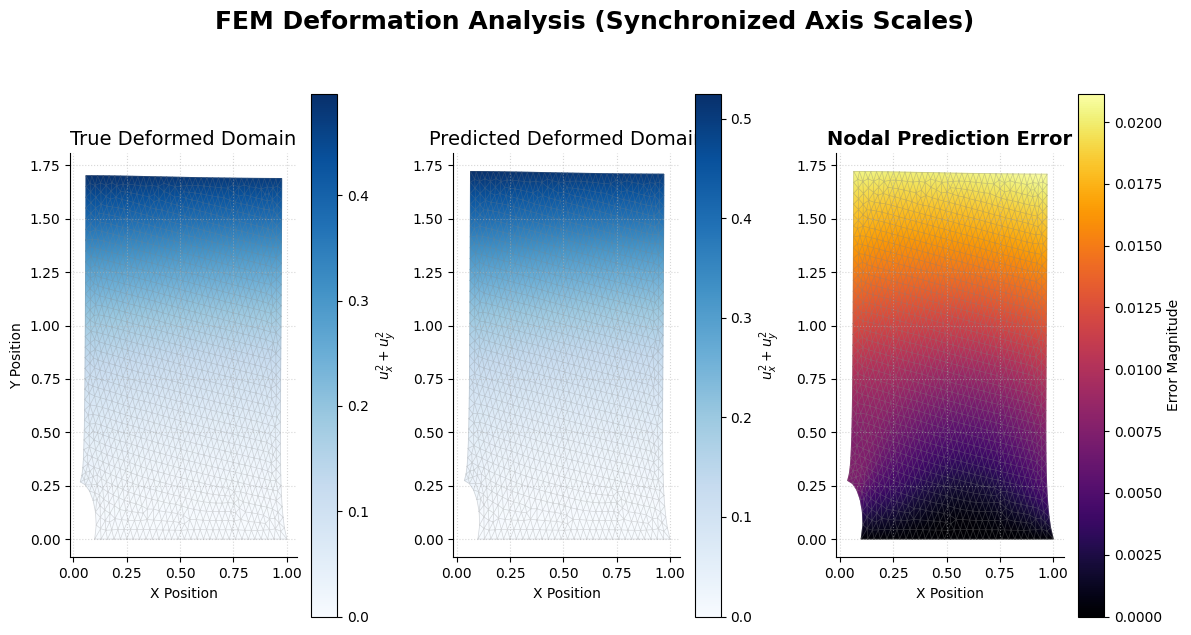

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.colors import LinearSegmentedColormap

# --- Color Definitions & Custom Colormap ---
COLOR_BLACK = '#000000'
COLOR_GREY  = '#808080'
COLOR_NAVY  = '#000080'
COLOR_ROYAL = '#4169E1'

# Creating a gradient: Black -> Grey -> Navy -> Royal
custom_cmap = LinearSegmentedColormap.from_list("fem_style", 
    [COLOR_BLACK, COLOR_GREY, COLOR_NAVY, COLOR_ROYAL], N=256)

# --- 1. Calculations ---
u_true_sq_mag = u_true[:, 0]**2 + u_true[:, 1]**2
u_pred_sq_mag = u_pred[:, 0]**2 + u_pred[:, 1]**2
u_error_mag = np.linalg.norm(u_true - u_pred, axis=1)

# Deformed nodal positions
wp_true = node_coords[:, :2] + u_true
wp_pred = node_coords[:, :2] + u_pred

# --- SCALE SYNCHRONIZATION ---
# Calculate GLOBAL limits across both True and Predicted deformed sets
all_x = np.concatenate([wp_true[:, 0], wp_pred[:, 0]])
all_y = np.concatenate([wp_true[:, 1], wp_pred[:, 1]])

x_min, x_max = all_x.min(), all_x.max()
y_min, y_max = all_y.min(), all_y.max()

# Add a 5% margin padding to the axes
x_margin = (x_max - x_min) * 0.05
y_margin = (y_max - y_min) * 0.05
x_lims = (x_min - x_margin, x_max + x_margin)
y_lims = (y_min - y_margin, y_max + y_margin)

# Create Triangulations
tri_true = tri.Triangulation(wp_true[:, 0], wp_true[:, 1], cells)
tri_pred = tri.Triangulation(wp_pred[:, 0], wp_pred[:, 1], cells)

# --- 2. Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(12, 6), facecolor='white')
fig.suptitle('FEM Deformation Analysis (Synchronized Axis Scales)', fontsize=18, fontweight='bold', y=1.05)

# Plot 1: True Deformed
ax1 = axes[0]
tpc1 = ax1.tripcolor(tri_true, u_true_sq_mag, cmap="Blues", shading='gouraud')
ax1.triplot(tri_true, color=COLOR_GREY, linewidth=0.5, alpha=0.3)
fig.colorbar(tpc1, ax=ax1, label='$u_x^2 + u_y^2$')
ax1.set_title('True Deformed Domain', fontsize=14)

# Plot 2: Predicted Deformed
ax2 = axes[1]
tpc2 = ax2.tripcolor(tri_pred, u_pred_sq_mag, cmap="Blues", shading='gouraud')
ax2.triplot(tri_pred, color=COLOR_GREY, linewidth=0.5, alpha=0.3)
fig.colorbar(tpc2, ax=ax2, label='$u_x^2 + u_y^2$')
ax2.set_title('Predicted Deformed Domain', fontsize=14)

# Plot 3: Absolute Error on Predicted Mesh
ax3 = axes[2]
tpc3 = ax3.tripcolor(tri_pred, u_error_mag, cmap='inferno', shading='gouraud')
ax3.triplot(tri_pred, color=COLOR_GREY, linewidth=0.5, alpha=0.4)
fig.colorbar(tpc3, ax=ax3, label='Error Magnitude')
ax3.set_title('Nodal Prediction Error', fontsize=14, fontweight='bold')

# --- Formatting & Applying Uniform Scale ---
for i, ax in enumerate(axes):
    ax.set_aspect('equal') # Maintain geometric proportions
    ax.set_xlim(x_lims)    # Synchronized X
    ax.set_ylim(y_lims)    # Synchronized Y
    ax.set_xlabel('X Position')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if i == 0:
        ax.set_ylabel('Y Position')

plt.tight_layout()
plt.show()

In [163]:
from core.utils import deformation_gradient_element

In [164]:
coords_cells = node_coords[cells]
u_pred_cells = u_pred[cells]
u_true_cells = u_true[cells]

In [165]:
f_pred, _ = deformation_gradient_element(coords_cells, u_pred_cells)
f_true, _ = deformation_gradient_element(coords_cells, u_true_cells)

In [166]:
f_pred

Array([[[ 0.92009, -0.03012],
        [ 0.02617,  1.66563]],

       [[ 0.9199 , -0.03031],
        [ 0.02714,  1.6666 ]],

       [[ 0.9201 , -0.03013],
        [ 0.03615,  1.66198]],

       [[ 0.9234 , -0.03987],
        [ 0.02679,  1.66754]],

       [[ 0.91568, -0.03283],
        [ 0.04156,  1.66528]],

       [[ 0.91916, -0.04096],
        [ 0.03687,  1.67012]],

       [[ 0.92079, -0.04426],
        [ 0.03034,  1.6735 ]],

       [[ 0.91791, -0.03426],
        [ 0.04768,  1.66134]],

       [[ 0.92021, -0.04171],
        [ 0.04229,  1.66627]],

       [[ 0.92272, -0.04843],
        [ 0.02993,  1.67437]],

       [[ 0.91306, -0.03692],
        [ 0.05435,  1.66499]],

       [[ 0.91774, -0.04298],
        [ 0.04783,  1.66913]],

       [[ 0.92084, -0.04811],
        [ 0.04169,  1.67231]],

       [[ 0.92145, -0.05036],
        [ 0.03235,  1.67806]],

       [[ 0.92074, -0.04822],
        [ 0.04239,  1.67305]],

       [[ 0.91691, -0.03952],
        [ 0.06009,  1.6611 ]],

       [

In [167]:
def _dev_input(invariants) :
    i3 = jnp.maximum(invariants[2], 1e-6)
    i1_dev = i3**(-1/3)*invariants[0]
    i2_dev = i3**(-2/3)*invariants[1]
    return jnp.stack([i1_dev, i2_dev, i3], axis = -1)

In [168]:
invariant_func = jax.vmap(invariants_and_derivatives)
i_pred, _ = invariant_func(f_pred)
i_true, _ = invariant_func(f_true)
vec_dev_input = jax.vmap(_dev_input)
i_pred_dev = vec_dev_input(i_pred)
i_true_dev = vec_dev_input(i_true)


<>:11: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:11: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_24278/2554034789.py:11: SyntaxWarning: invalid escape sequence '\o'
  labels = ['$I_1 = \operatorname{tr}{C}$',
/tmp/ipykernel_24278/2554034789.py:13: SyntaxWarning: invalid escape sequence '\o'
  '$I_3 = \operatorname{det}(C)$']


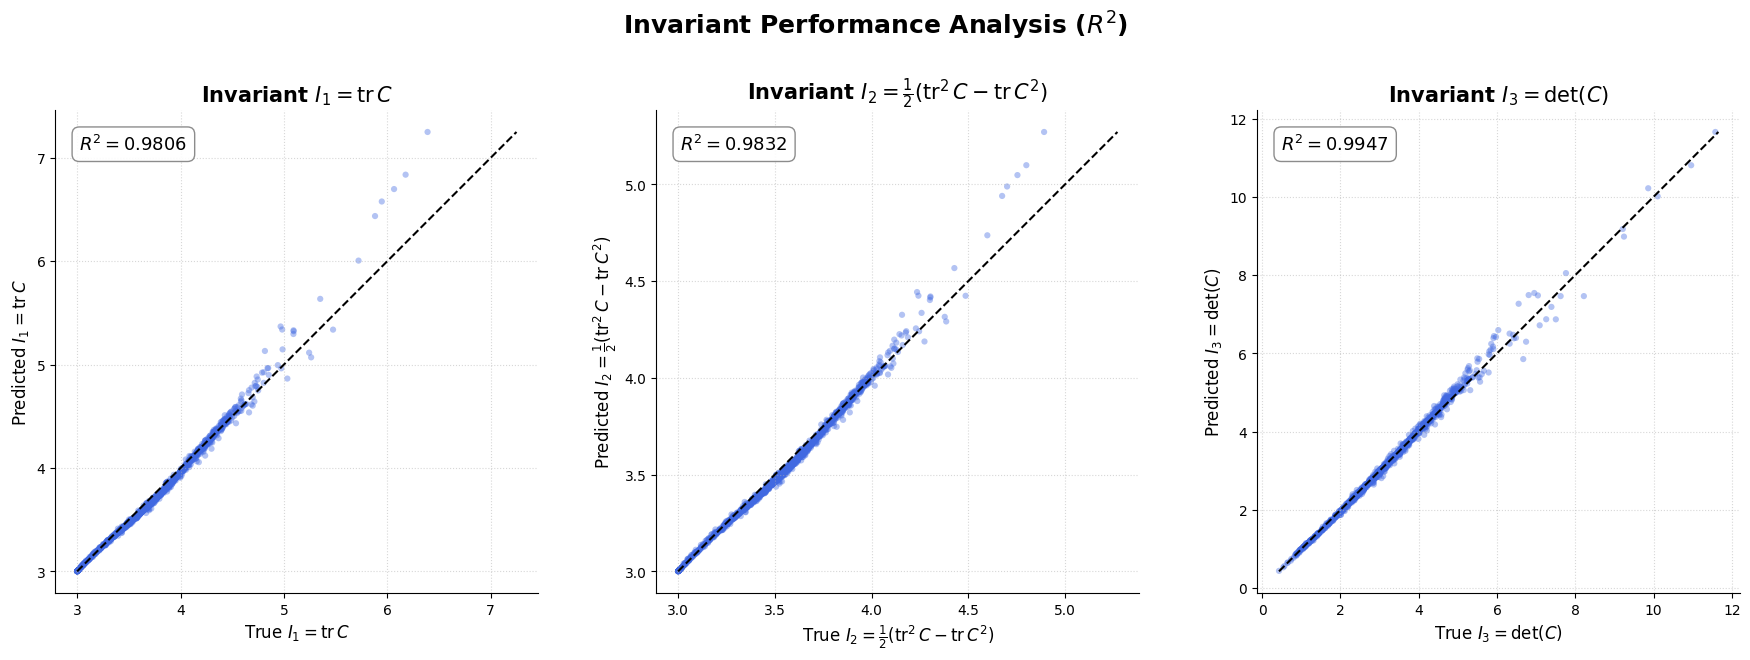

In [172]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# --- Color Palette ---
COLOR_BLACK = '#000000'
COLOR_ROYAL = '#4169E1'
COLOR_GREY  = '#808080'

# Assuming true_invariant and pred_invariant are (#data, 3) arrays
labels = ['$I_1 = \operatorname{tr}{C}$', 
          r'$I_2 = \frac{1}{2} (\operatorname{tr}^2{C} - \operatorname{tr}{C^2})$', 
          '$I_3 = \operatorname{det}(C)$']

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='white')
fig.suptitle('Invariant Performance Analysis ($R^2$)', fontsize=18, fontweight='bold', y=1.05)

for i in range(3):
    ax = axes[i]
    y_true = i_true_dev[:, i]
    y_pred = i_pred_dev[:, i]
    
    # Calculate R2 score
    score = r2_score(y_true, y_pred)
    
    # Scatter Plot (Royal Blue points with transparency for density)
    ax.scatter(y_true, y_pred, color=COLOR_ROYAL, alpha=0.4, s=20, edgecolors='none')
    
    # Identity Line (y=x) in Black
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], color=COLOR_BLACK, linestyle='--', linewidth=1.5, label='Ideal')
    
    # Formatting
    ax.set_title(f'Invariant {labels[i]}', fontsize=15, fontweight='bold')
    ax.set_xlabel(f'True {labels[i]}', fontsize=12)
    ax.set_ylabel(f'Predicted {labels[i]}', fontsize=12)
    
    # Display R2 Score in a box
    ax.text(0.05, 0.95, f'$R^2 = {score:.4f}$', transform=ax.transAxes, 
            fontsize=13, fontweight='bold', verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor=COLOR_GREY))
    
    # Styling
    ax.set_aspect('equal') # Important for parity plots to keep the slope visually correct
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()